This is an attempt to drastically speed up the drizzle-like approach from [single_forward_model4_build2d.ipynb](single_forward_model4_build2d.ipynb) using JAX.  Note, all data are fake but of comparable dimension.

In [1]:
import time

from matplotlib import pyplot as plt

import numpy as np
import jax
from jax import numpy as jnp

from tqdm.auto import tqdm

rkey = jax.random.key(42)
jax.devices()

[CudaDevice(id=0)]

# Mock data

Make fake "data" of a dimensionality that's not crazy, and populate it with some random nans

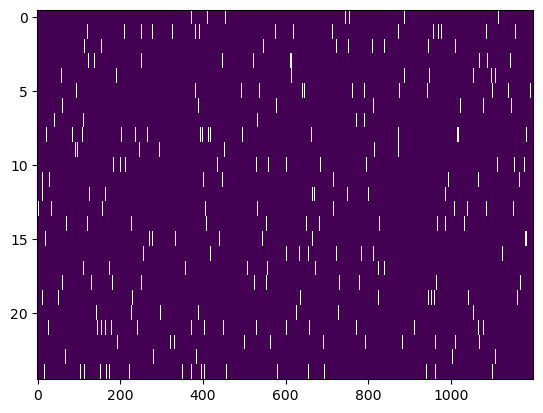

In [2]:
slit = jnp.zeros((25, 1200))

rkey, subkey = jax.random.split(rkey)
nanmsk = jax.random.uniform(subkey, slit.shape)>.98

slit = slit.at[nanmsk].set(jnp.nan)

plt.imshow(slit,aspect='auto', interpolation='nearest')

Make a fake spectrum that's somewhat denser than the "data"

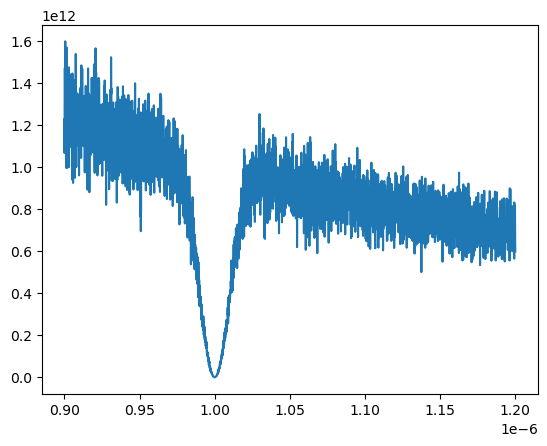

In [3]:
wave_m = jnp.linspace(0.9e-6, 1.2e-6, 4096)
spectrum = jnp.ones_like(wave_m)

rkey, subkey = jax.random.split(rkey)

# this spectrum is artificially noisy with a single bit aborption line.
spectrum = spectrum + 0.1 * jax.random.normal(subkey, shape=spectrum.shape)
spectrum = spectrum * (1-jnp.exp(-0.5*((wave_m - 1.e-6)/10e-9)**2))
spectrum_fnu = spectrum  * wave_m**-2

plt.plot(wave_m, spectrum_fnu)

Make a fake slightly noisy psf that is ~200x200 with 10x oversampling

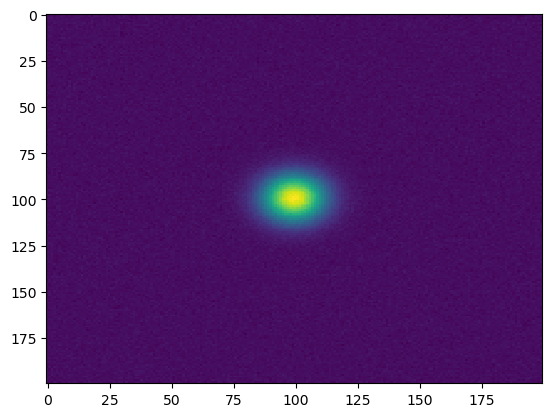

In [4]:
psf_box = (20,20)
oversampling = 10

psfcen_x = psfcen_y = 0

ys, xs = jnp.indices((psf_box[0]*oversampling, psf_box[1]*oversampling)).astype(float)
ys -= (ys.shape[0]-1)/2
xs -= (xs.shape[1]-1)/2

psf_x = (xs - psfcen_x)/oversampling
psf_y = (ys - psfcen_y)/oversampling

os_psf = jnp.exp(-0.5*(psf_x**2 + psf_y**2)/(.9**2))

rkey, subkey = jax.random.split(rkey)
os_psf = os_psf + 0.01 * jax.random.normal(subkey, shape=os_psf.shape)

plt.imshow(os_psf, aspect='auto', interpolation='nearest')

And now make a spectral trace that's curvy

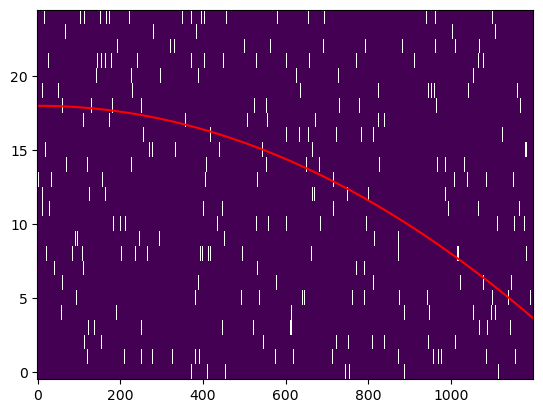

In [5]:
def tracefunc(x):
    return 18 - 10*(x/1000)**2

xtrace = np.arange(slit.shape[1])
ytrace = tracefunc(xtrace)

plt.imshow(slit,aspect='auto', interpolation='nearest', origin='lower')
plt.plot(xtrace, ytrace, color='red')

Note the biggest difference is that the real data have a lot more nans, but this smattering should be sufficient to catch relevant bugs.

In [6]:
xspec = np.arange(wave_m.size)/wave_m.size * slit.shape[1]
yspec = tracefunc(xspec)

Array([1161,   -6], dtype=int32)

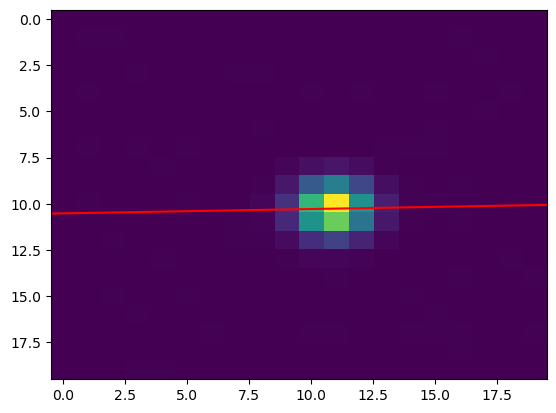

In [217]:
spaxel_shape = (psf_x.shape[0]//oversampling, psf_x.shape[1]//oversampling)

def single_spaxel(xi, yi, wli, fnui, psfi):
    xs = psf_x + xi
    ys = psf_y + yi

    spaxel_corner = jnp.array((jnp.floor(jnp.min(xs)).astype(int),
                               jnp.floor(jnp.min(ys)).astype(int)))
    
    spaxel_y, spaxel_x = jnp.indices(spaxel_shape)
    spaxel_x = spaxel_x + spaxel_corner[0]
    spaxel_y = spaxel_y + spaxel_corner[1]

    dx = jnp.subtract.outer(xs, spaxel_x)
    dy = jnp.subtract.outer(ys, spaxel_y)

    fx = jnp.clip(oversampling*-jnp.abs(dx) + (1+oversampling)/2, 0, 1)
    fy = jnp.clip(oversampling*-jnp.abs(dy) + (1+oversampling)/2, 0, 1)
    f = fx*fy * fnui

    pp = psfi[:,:, jnp.newaxis, jnp.newaxis] * f
    data = jnp.sum(pp, axis=(0, 1))

    return data, spaxel_corner

idx = 4000
test_data, test_corner = single_spaxel(xspec[idx], yspec[idx], wave_m[idx], spectrum_fnu[idx], os_psf)

plt.imshow(test_data, aspect='auto', interpolation='nearest')
xl = plt.xlim()
yl = plt.ylim()
plt.plot(xtrace-test_corner[0], ytrace-test_corner[1], color='red')
plt.xlim(xl)
plt.ylim(yl)

test_corner

In [8]:
single_spaxel_jit = jax.jit(single_spaxel)
single_spaxel_jit(xspec[idx], yspec[idx], wave_m[idx], spectrum_fnu[idx], os_psf)[0].block_until_ready()


st = time.time()
single_spaxel_jit(xspec[idx], yspec[idx], wave_m[idx], spectrum_fnu[idx], os_psf)[0].block_until_ready()
et = time.time()
et - st, (et-st)*wave_m.size

(0.0009791851043701172, 4.0107421875)

In [9]:
single_spaxel_vmap = jax.vmap(single_spaxel_jit, in_axes=(0, 0,0,0, None))
batch_size = 64

single_spaxel_vmap(xspec[:batch_size], yspec[:batch_size], wave_m[:batch_size], spectrum_fnu[:batch_size], os_psf)[0].block_until_ready()

st = time.time()
single_spaxel_vmap(xspec[:batch_size], yspec[:batch_size], wave_m[:batch_size], spectrum_fnu[:batch_size], os_psf)[0].block_until_ready()
et = time.time()
et - st, (et-st)*wave_m.size/batch_size

(0.005936384201049805, 0.3799285888671875)

0.24764728546142578

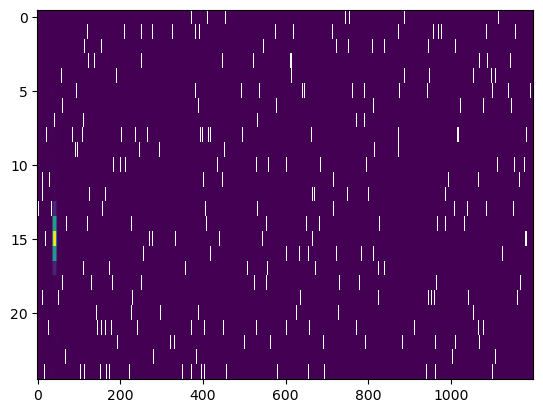

In [218]:
@jax.jit(static_argnums=(6, ))
def do_batch(xspec, yspec, wave_m, spectrum_fnu, os_psf, start_slit, batch_size=32, batch_start=0):
    batch_slice = slice(batch_start, batch_start + batch_size)
    a = jax.lax.dynamic_slice(xspec, (batch_start,), (batch_size,), allow_negative_indices=True)
    b = jax.lax.dynamic_slice(yspec, (batch_start,), (batch_size,), allow_negative_indices=True)
    c = jax.lax.dynamic_slice(wave_m, (batch_start,), (batch_size,), allow_negative_indices=True)
    d = jax.lax.dynamic_slice(spectrum_fnu, (batch_start,), (batch_size,), allow_negative_indices=True)
    data, corners = single_spaxel_vmap(a, b, c, d, os_psf)

    def scanf(currslit, xi):
        data, corners = xi
        newslice = data + jax.lax.dynamic_slice(currslit, corners[::-1], spaxel_shape, allow_negative_indices=True)
        return jax.lax.dynamic_update_slice(currslit, newslice, corners[::-1], allow_negative_indices=True), None


    return jax.lax.scan(scanf, start_slit, (data, corners))[0]

st = time.time()
res = do_batch(xspec, yspec, wave_m, spectrum_fnu, os_psf, slit, batch_start=128).block_until_ready()
et = time.time()

plt.imshow(res, interpolation='nearest', aspect='auto')

et - st

0.5037181377410889

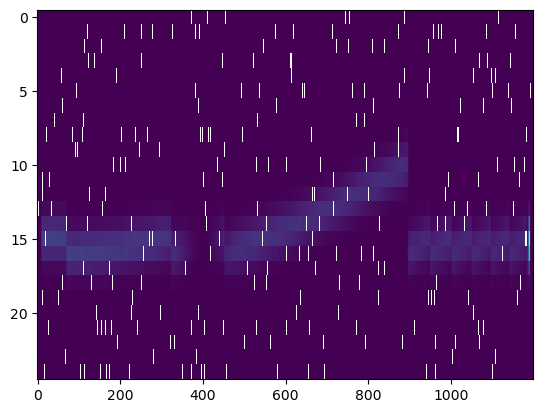

In [219]:
@jax.jit(static_argnums=(5,))
def batch_all(xspec, yspec, wave_m, spectrum_fnu, os_psf, batch_size=32):
    def forf(i, currslit):
        batchslit = do_batch(xspec, yspec, wave_m, spectrum_fnu, os_psf, currslit, batch_size, i*batch_size)
        return batchslit
    
    return jax.lax.fori_loop(0, xspec.shape[0]//batch_size, forf, slit)


st = time.time()
res = batch_all(xspec, yspec, wave_m, spectrum_fnu, os_psf, batch_size=32).block_until_ready()
et = time.time()
plt.imshow(res, interpolation='nearest', aspect='auto')
et - st

Grr, the corners are a problem here.  At this point I think a custom kernel is needed.